In [31]:
import ee
import os
import geemap
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [179]:
import data_utils
import gee_utils
import plotting

importlib.reload(data_utils)
importlib.reload(gee_utils)
importlib.reload(plotting)

<module 'plotting' from '/Users/bensutton/Projects/dissertation-code/src/plotting.py'>

In [180]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from features_utils import add_indices, correlation_matrix
from plotting import set_pubr_theme, pubr_legend, pubr_fill

In [4]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points.csv"
indices_fp = PROJECT_ROOT / "configs" / "indices.json"


In [24]:
samples = pd.read_csv(sample_fp)

samples_w_indices = add_indices(samples, indices_file= indices_fp)

sample_indices_fp = PROJECT_ROOT / "outputs" / "sample_points_indices.csv"

samples_w_indices.to_csv(sample_indices_fp, index= False)

In [25]:
samples_w_indices.describe()

/Users/bensutton/Projects/dissertation-code/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,...,NDBI,NDAVI,RR1,EVI,SAVI,DVI,OSAVI,AWEIsh,SABI,BSI
count,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,...,16019.000000,15969.000000,15984.000000,16019.000000,16019.000000,16019.000000,16019.000000,16019.000000,1.598600e+04,16019.000000
mean,949.632374,513.358949,362.550534,587.801174,408.123166,833.925464,1793.578625,2079.123229,2189.358886,2173.199638,...,-0.371202,0.473875,0.321585,0.337168,0.704427,1601.557713,0.469420,-3004.773160,NaN,-0.281470
std,812.529812,529.966619,226.800637,307.401317,336.697329,488.614459,1320.778799,1579.768732,1633.304076,1688.305718,...,0.281728,0.475609,0.208707,0.285608,0.669746,1504.761351,0.447307,3124.874978,NaN,0.221788
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-0.196994,-1.498878,-3681.000000,-0.999761,-11868.250000,-inf,-0.770482
25%,181.000000,117.000000,245.000000,411.000000,240.000000,459.000000,455.500000,477.000000,473.500000,387.000000,...,-0.543788,0.187588,0.161010,0.033024,0.201706,28.000000,0.134482,-5417.750000,1.684290e-01,-0.446358
50%,856.000000,399.000000,335.000000,558.000000,333.000000,824.000000,1819.000000,2058.000000,2254.000000,2185.000000,...,-0.449591,0.711667,0.366844,0.356785,1.027718,1575.000000,0.685217,-3219.250000,1.786402e+00,-0.336306
75%,1479.000000,700.000000,436.000000,734.000000,458.000000,1108.000000,2743.000000,3217.000000,3372.000000,3431.000000,...,-0.256154,0.814984,0.484090,0.568427,1.209074,2698.000000,0.806126,85.625000,3.040345e+00,-0.148002
max,6253.000000,6091.000000,7784.000000,7312.000000,7704.000000,4931.000000,6119.000000,7185.000000,7632.000000,7480.000000,...,1.000000,1.000000,1.000000,1.635764,1.499864,6126.000000,0.999971,12202.000000,inf,1.000000


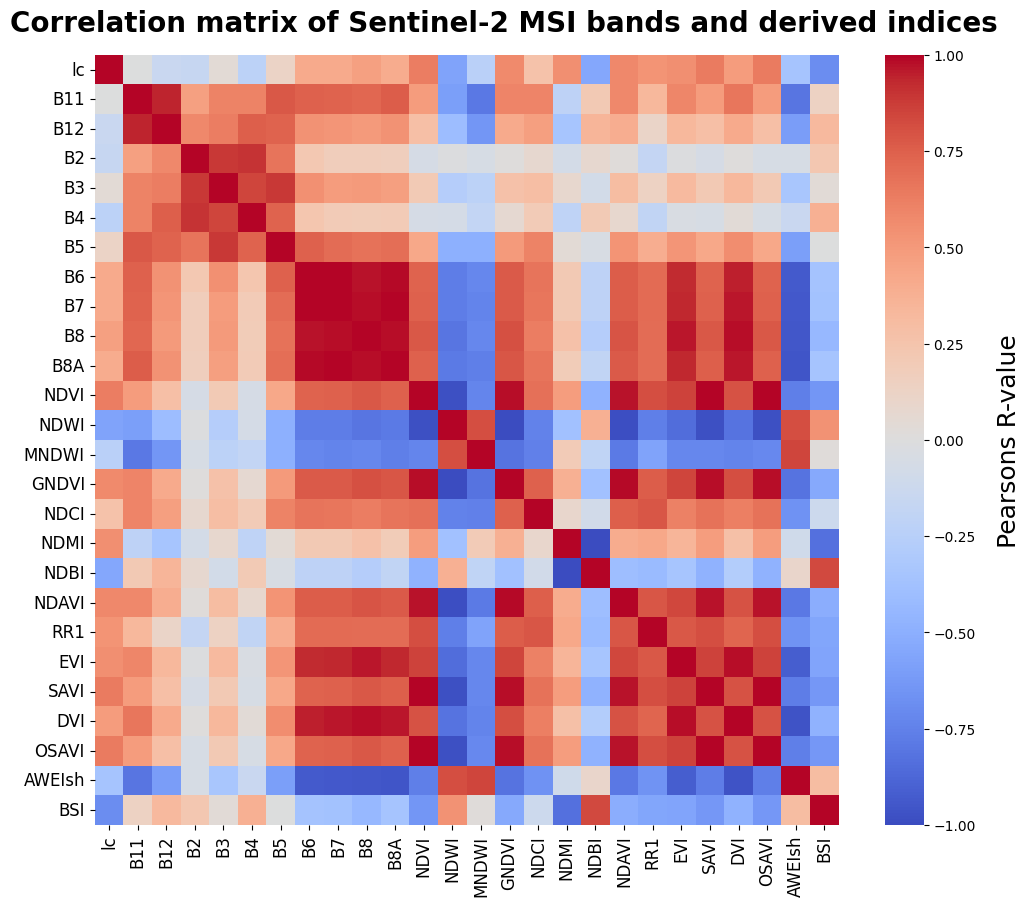

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bensutton/Projects/outputs/corr_matrix.png'

In [30]:
corr = correlation_matrix(samples_w_indices, columns= ['lc','B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'NDVI', 'NDWI',
       'MNDWI', 'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'NDAVI', 'RR1', 'EVI', 'SAVI',
       'DVI', 'OSAVI', 'AWEIsh', 'BSI'])



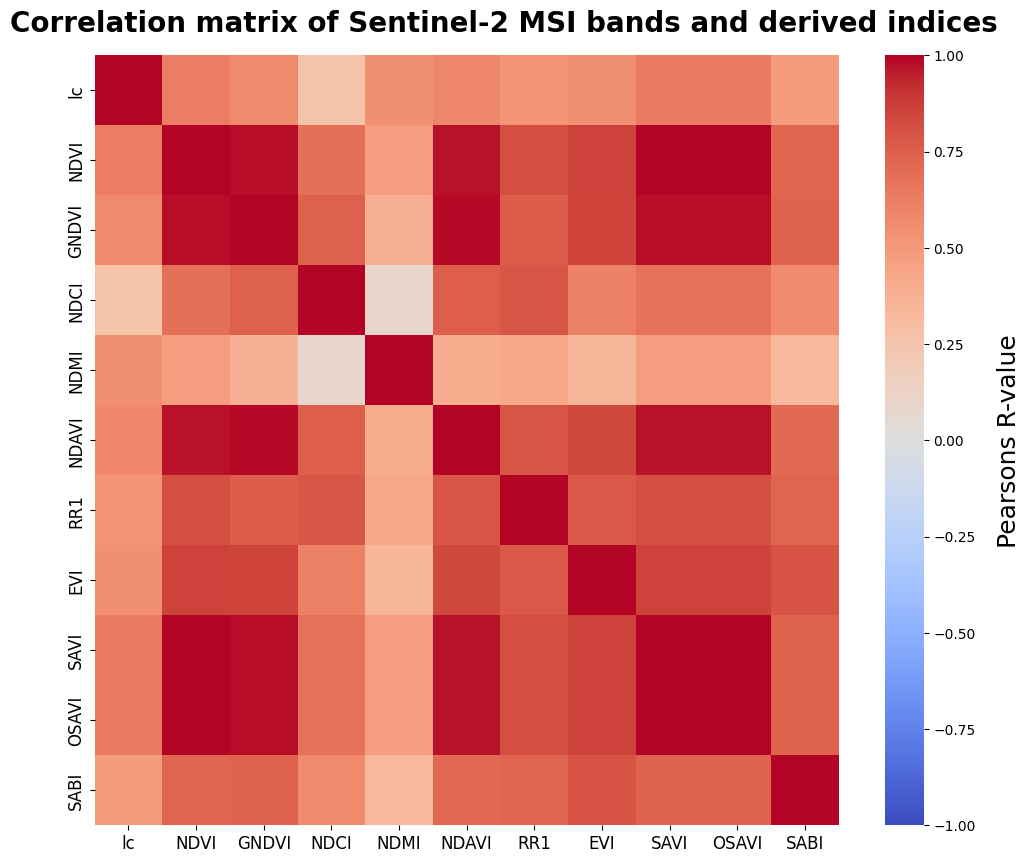

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bensutton/Projects/outputs/corr_matrix.png'

In [26]:
veg_columns = ['lc','NDVI','GNDVI', 'NDCI', 'NDMI','NDAVI', 'RR1', 'EVI', 'SAVI','OSAVI', 'SABI']

veg_corr = correlation_matrix(samples_w_indices, columns= veg_columns)

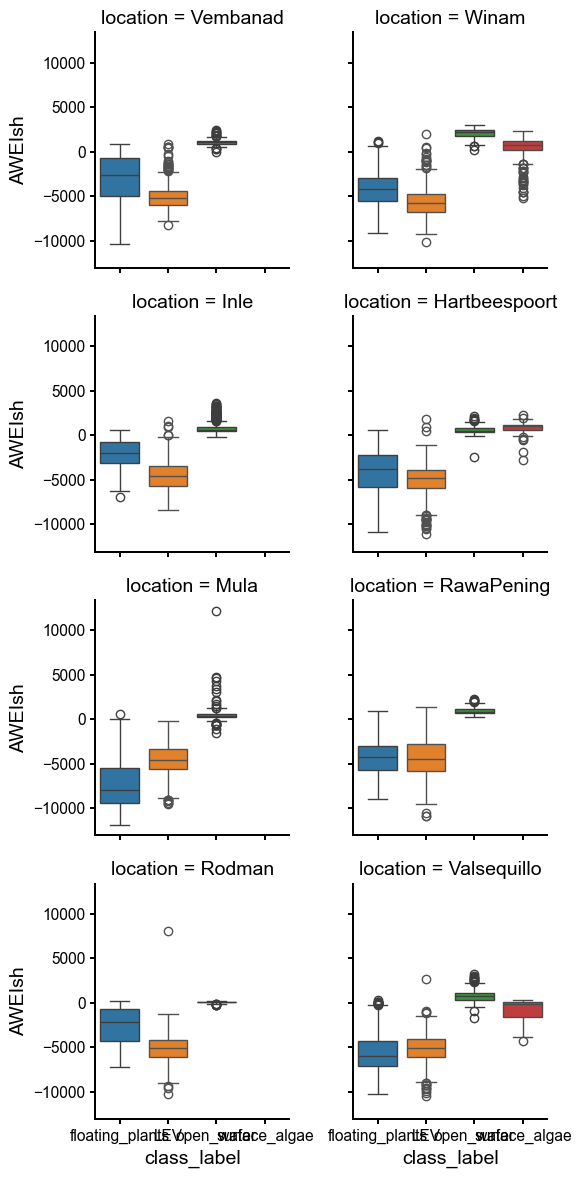

In [120]:
# Boxplots of bands and indices by class

g = sns.FacetGrid(samples_w_indices, col = "location", col_wrap = 2, hue = "class_label")
g.map_dataframe(sns.boxplot, y = "AWEIsh", x = "class_label"
                 )

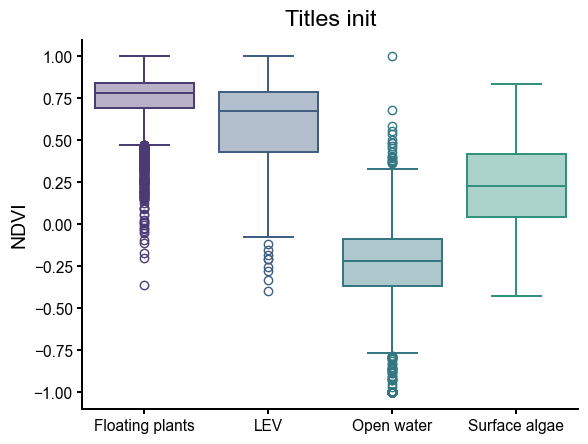

In [185]:

sns.set_palette("viridis") # Sets palette for seaborn globally

# Create a clean class labels column for display

labels = {
    "floating_plants": "Floating plants",
    "LEV": "LEV",
    "open_water": "Open water",
    "surface_algae": "Surface algae",
}

samples_w_indices["Class"] = samples_w_indices["class_label"].map(labels)
# or could map a new column using the above dict, this sureently wont change the xlabel names
fig, ax = plt.subplots()
set_pubr_theme(base_size=14)
sns.boxplot(data=samples_w_indices, 
            x="Class",
            y="NDVI",
            hue = "Class", 
            legend= False, 
            ax=ax)

pubr_legend(ax =ax, position= "top", relabel= labels)
pubr_fill(ax, alpha= 0.4, linewidth=None, legend = ax.get_legend())
ax.set_title("Titles init", pad = 10)
ax.set_xlabel("")
ax.set_ylabel("NDVI")
plt.show()

<Axes: title={'center': 'Vembanad'}, ylabel='AWEIsh'>

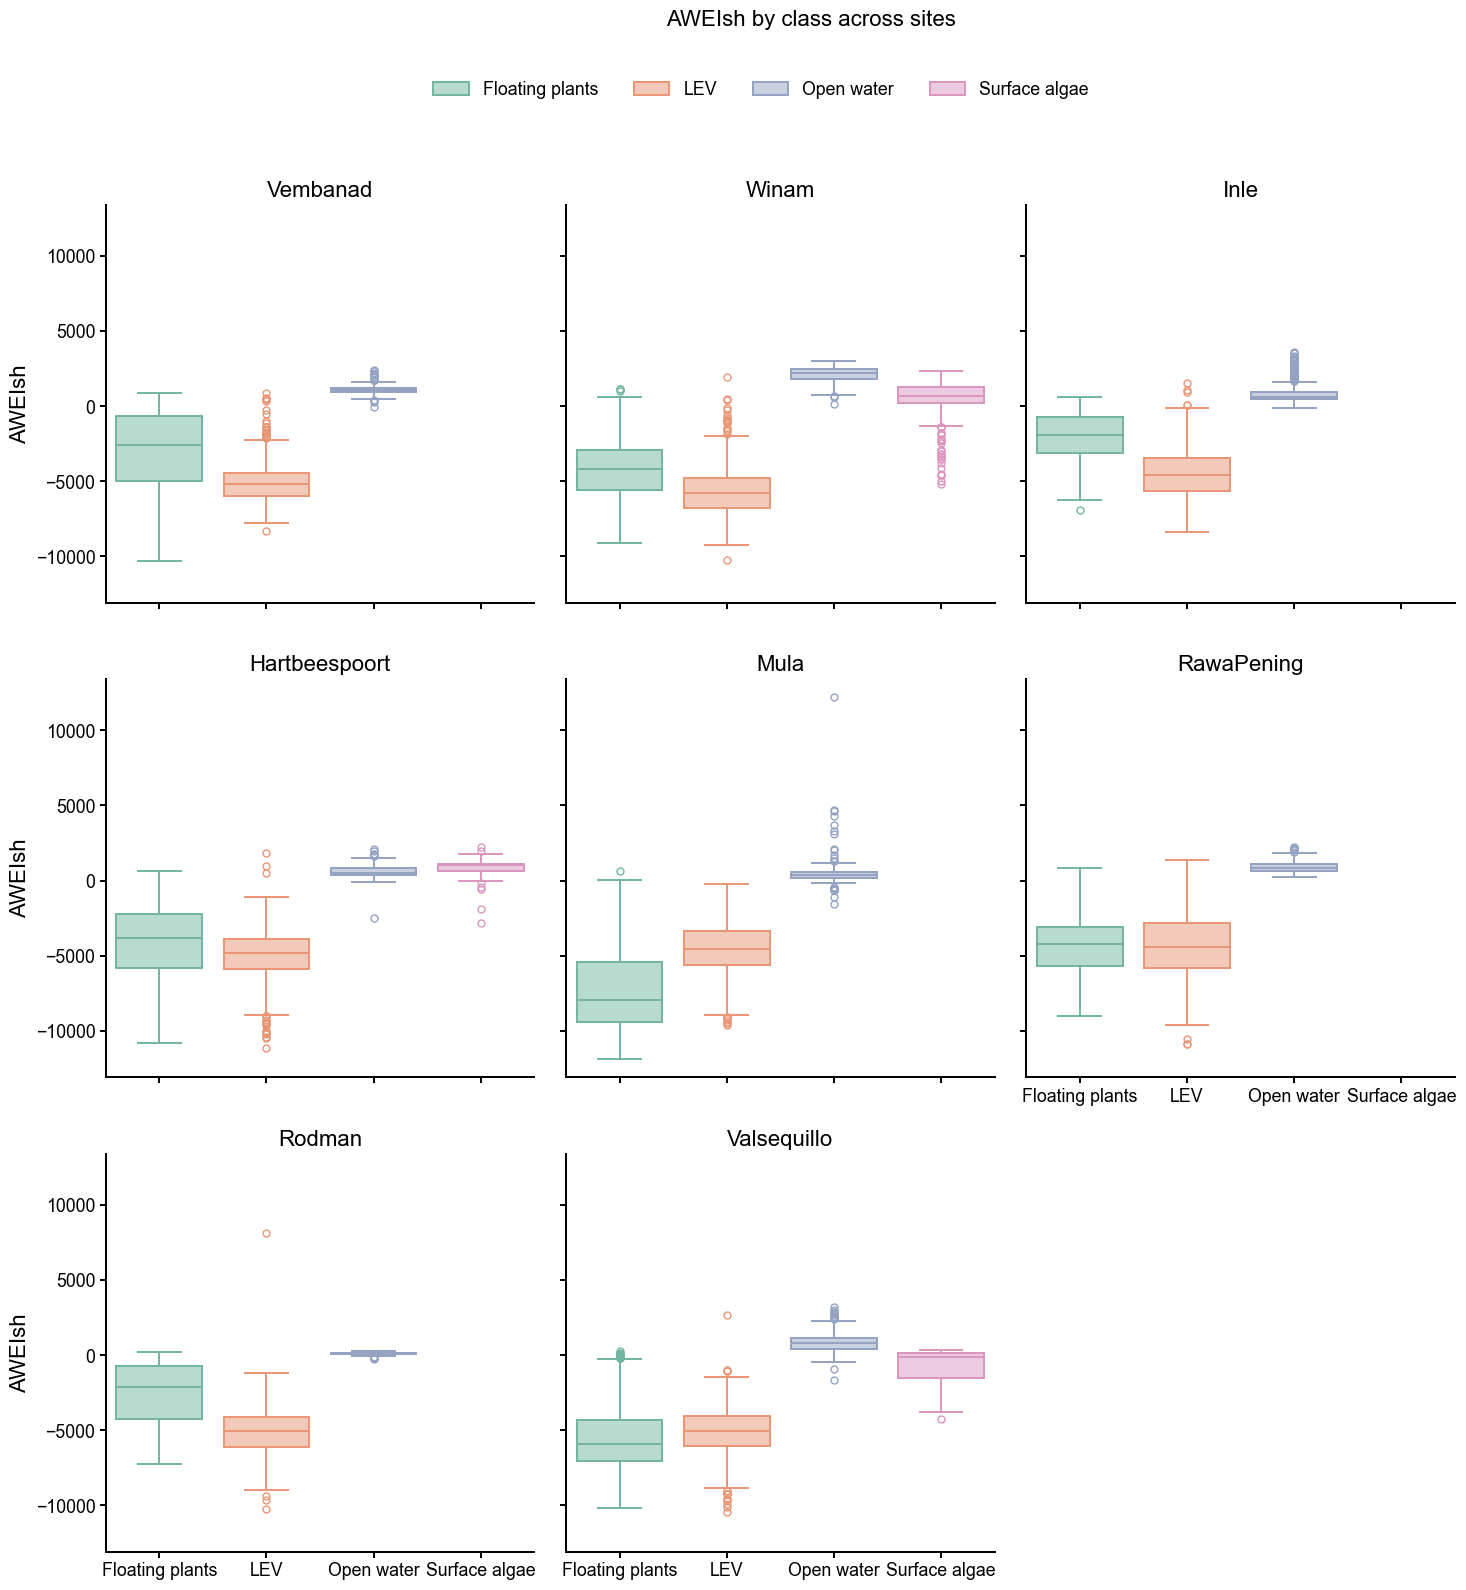

In [189]:
set_pubr_theme(base_size=16)

g = sns.catplot(
    data=samples_w_indices, kind="box",
    x="Class", y="AWEIsh", hue="Class",
    col="location",          # facet_wrap(~site)
    col_wrap=3,          # wrap after 3 columns
    palette="Set2",
    legend= True
)
g.set_titles("{col_name}")


for ax in g.axes.flat:          # pubr_fill is per-axes
    pubr_fill(ax)
    ax.set_xlabel("")

g.figure.suptitle("AWEIsh by class across sites", y=1.08, fontsize=16)
g.figure.subplots_adjust(top=0.95)        # make room so it isn't clipped

sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.47, 1.01),   # just above the grid
    ncol=4,             # one row
    frameon=False,
    title=None,                  # drop the legend title if you want
)

pubr_fill(g.axes.flat[0], legend=g._legend)

<Axes: title={'center': 'NDVI'}>

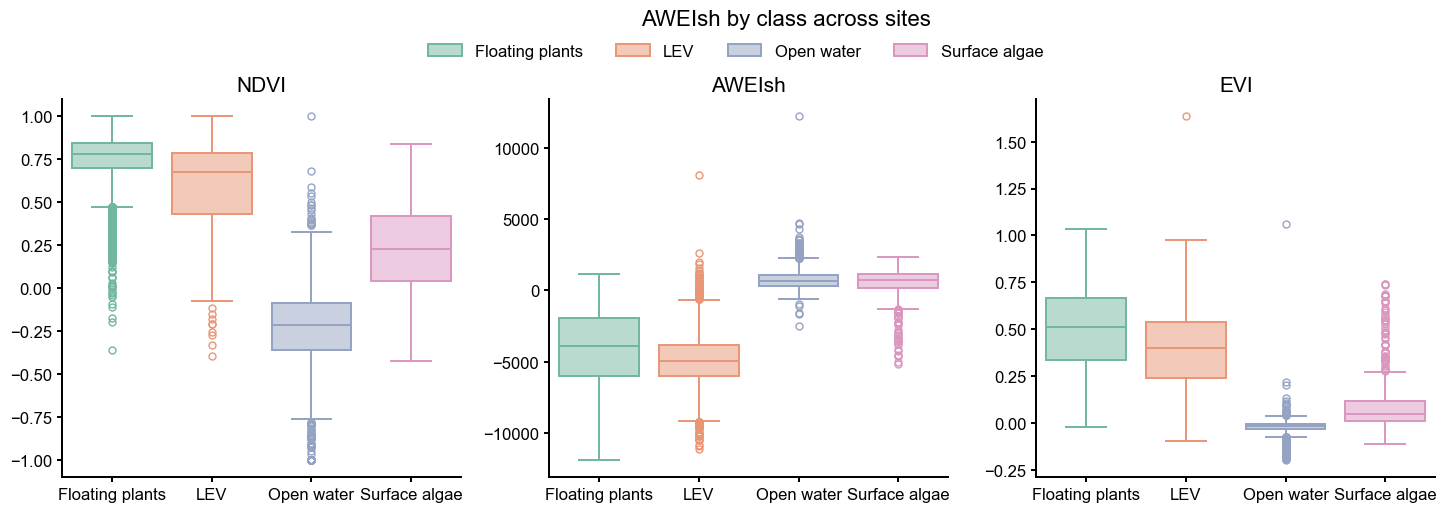

In [187]:
col_plot = ["NDVI", "AWEIsh", "EVI"]

long = samples_w_indices.melt(
    id_vars=["Class", "location"],     # columns to keep
    value_vars=col_plot,               # the indices to stack
    var_name="index",                  # new column holding "NDVI"/"AWEIsh"/"EVI"
    value_name="value",                # new column holding the numbers
)

set_pubr_theme(base_size=15)

g = sns.catplot(
    data=long, kind="box",
    x="Class", y="value",
    hue="Class",
    col="index",                       # facet_wrap(~index)
    col_order=col_plot,                # keep your list's order
    col_wrap=3,
    palette="Set2",
    sharey=False,                      # indices have different scales!
    legend=True,
)
g.set_titles("{col_name}")             # NDVI / AWEIsh / EVI

g.figure.suptitle("AWEIsh by class across sites", y=1.08, fontsize=16)
g.figure.subplots_adjust(top=0.9)        # make room so it isn't clipped

for ax in g.axes.flat:
    pubr_fill(ax)
    ax.set_xlabel("")
    ax.set_ylabel("")                  # otherwise every panel says "value"

sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.47, 0.95),
    ncol=4,
    frameon=False,
    title=None,
)

pubr_fill(g.axes.flat[0], legend=g._legend)